# Daily statistics: `get_stats_por` and `get_stats_date_range`

`get_stats_por` and `get_stats_date_range` return pre-computed temporal
statistics from the [modernized statistics API](https://api.waterdata.usgs.gov/statistics/v0/docs),
the modern replacement for the legacy NWIS statistics service. The two functions wrap
endpoints that look similar but answer different questions:

| Function | API endpoint | Returns |
| --- | --- | --- |
| `get_stats_por` | `observationNormals` | day-of-year and month-of-year statistics across the period of record |
| `get_stats_date_range` | `observationIntervals` | monthly and annual statistics within a requested date range |

A couple of usage notes:

- Pass `computation_type=` to choose the statistic — `arithmetic_mean`,
  `median`, `minimum`, `maximum`, or `percentile`.
- There is no dedicated argument to return only day-of-year vs. month-of-year
  (or only calendar vs. water year), so filter the returned `time_of_year_type`
  / `interval_type` column in pandas, as shown below.

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from dataretrieval import waterdata

%matplotlib inline

site = "USGS-02037500"

## Fetching day-of-year and month-of-year statistics

Day-of-year and month-of-year statistics aggregate observations for the same
calendar day or month across many years to describe typical seasonal conditions
(all Januarys, or all January 1sts). Below we request day-of-year discharge
averages for January 1 and 2 — note `start_date`/`end_date` are in `MM-DD`
format:

In [2]:
jan_por_mean, _ = waterdata.get_stats_por(
    monitoring_location_id=site,
    parameter_code="00060",
    computation_type="arithmetic_mean",
    start_date="01-01",
    end_date="01-02",
)
jan_por_mean[["time_of_year", "time_of_year_type", "computation", "value"]]

Retrieving: observationNormals · 1 page · 3 rows


No API key detected — register for higher rate limits at https://api.waterdata.usgs.gov/signup/


,time_of_year,time_of_year_type,computation,value
0,01-01,day_of_year,arithmetic_mean,9342.396
1,01-02,day_of_year,arithmetic_mean,9437.714
2,01,month_of_year,arithmetic_mean,7118.02


The first two rows are the day-of-year averages. What's the third row? Its
`time_of_year_type` is `month_of_year` — it's the average across all *Januarys*.
This is a quirk of the statistics API: whenever the `start_date`–`end_date` range
overlaps the first day of a month (here `01-01`), you also get the month-of-year
summary.

To return only one type, filter the `time_of_year_type` column — here,
month-of-year only:

In [3]:
moy = jan_por_mean[jan_por_mean["time_of_year_type"] == "month_of_year"]
moy[["time_of_year", "time_of_year_type", "computation", "value"]]

,time_of_year,time_of_year_type,computation,value
2,01,month_of_year,arithmetic_mean,7118.02


### Percentile band plot

Now an example that shows the power of the statistics API: we pull *all*
day-of-year discharge percentiles for the site. Computing these without the API
would mean downloading the entire daily period of record and computing
percentiles by hand.

By default `get_stats_por` sets `expand_percentiles=True`, returning one row per
percentile with the value in `value` and the threshold in `percentile`
(minimum is reported as percentile 0, maximum as 100).

In [4]:
full_por_percentiles, _ = waterdata.get_stats_por(
    monitoring_location_id=site,
    parameter_code="00060",
    computation_type=["minimum", "maximum", "percentile"],
    start_date="01-01",
    end_date="12-31",
)
# The January 1 day-of-year percentiles (used on the WDFN state pages):
jan1 = full_por_percentiles[
    (full_por_percentiles["time_of_year"] == "01-01")
    & (full_por_percentiles["time_of_year_type"] == "day_of_year")
]
jan1.sort_values("percentile")[["time_of_year", "computation", "percentile", "value"]]

Retrieving: observationNormals · 1 page · 1,134 rows

,time_of_year,computation,percentile,value
378,01-01,minimum,0.0,380.0
0,01-01,percentile,5.0,1266.0
1,01-01,percentile,10.0,1922.0
2,01-01,percentile,25.0,3580.0
3,01-01,percentile,50.0,5550.0
4,01-01,percentile,75.0,9890.0
5,01-01,percentile,90.0,22000.0
6,01-01,percentile,95.0,37780.0
0,01-01,maximum,100.0,60000.0


Pivoting the day-of-year rows so each percentile is a column lets us draw the
percentile "ribbons" — each band spans two adjacent percentiles (min–5th, 5th–10th, …):

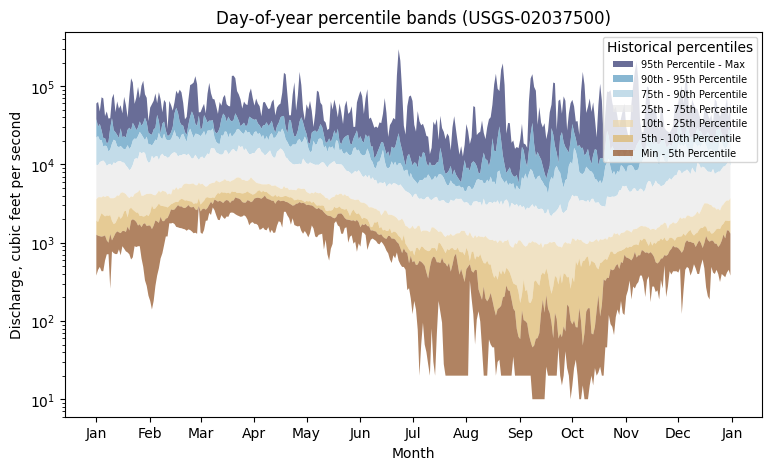

In [5]:
doy = full_por_percentiles[
    full_por_percentiles["time_of_year_type"] == "day_of_year"
].copy()
doy["value"] = pd.to_numeric(doy["value"], errors="coerce")  # API returns strings
bands = doy.pivot_table(index="time_of_year", columns="percentile", values="value")
bands.columns = [int(c) for c in bands.columns]
bands = bands.sort_index()  # "MM-DD" strings sort chronologically within a year

# x positions: map MM-DD onto a reference (leap) year so 02-29 is included
x = pd.to_datetime("2024-" + bands.index, format="%Y-%m-%d")

# (lo, hi) percentile range, fill color, legend label
band_defs = [
    ((95, 100), "#292f6b", "95th Percentile - Max"),
    ((90, 95), "#5699c0", "90th - 95th Percentile"),
    ((75, 90), "#aacee0", "75th - 90th Percentile"),
    ((25, 75), "#e9e9e9", "25th - 75th Percentile"),
    ((10, 25), "#ebd6ab", "10th - 25th Percentile"),
    ((5, 10), "#dcb668", "5th - 10th Percentile"),
    ((0, 5), "#8f4f1f", "Min - 5th Percentile"),
]

fig, ax = plt.subplots(figsize=(9, 5))
for (lo, hi), color, label in band_defs:
    ax.fill_between(x, bands[lo], bands[hi], facecolor=color, alpha=0.7, label=label)
ax.set_yscale("log")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlabel("Month")
ax.set_ylabel("Discharge, cubic feet per second")
ax.set_title("Day-of-year percentile bands (USGS-02037500)")
ax.legend(title="Historical percentiles", fontsize=7, loc="upper right")
plt.show()

Finally, overlay the actual daily mean discharge so we can see where recent
conditions fall relative to the historical bands — exactly the view on the
[Water Data for the Nation (WDFN) statistical graphs](https://waterdata.usgs.gov/monitoring-location/USGS-02037500/statistical-graphs/).
We pull two water years of daily means and join them to the bands by month-day.

Retrieving: daily · 1 page · 731 rows

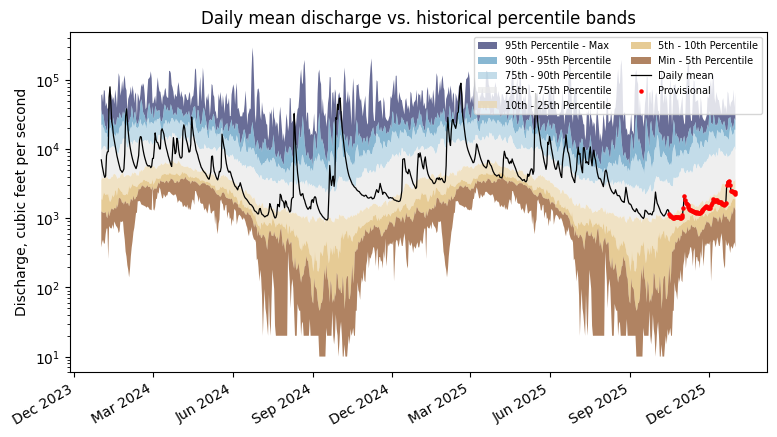

In [6]:
daily, _ = waterdata.get_daily(
    monitoring_location_id=site,
    parameter_code="00060",
    statistic_id="00003",
    time=["2024-01-01", "2025-12-31"],
)
daily = daily.sort_values("time").reset_index(drop=True)
daily["md"] = daily["time"].dt.strftime("%m-%d")

# Repeat the day-of-year bands across each actual calendar date
b = bands.reindex(daily["md"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
for (lo, hi), color, label in band_defs:
    ax.fill_between(
        daily["time"], b[lo], b[hi], facecolor=color, alpha=0.7, label=label
    )
ax.plot(daily["time"], daily["value"], color="black", lw=0.9, label="Daily mean")
prov = daily[daily["approval_status"] == "Provisional"]
ax.scatter(prov["time"], prov["value"], color="red", s=5, zorder=3, label="Provisional")
ax.set_yscale("log")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("Discharge, cubic feet per second")
ax.set_title("Daily mean discharge vs. historical percentile bands")
ax.legend(fontsize=7, ncol=2, loc="upper right")
fig.autofmt_xdate()
plt.show()

## Fetching monthly and annual statistics within a date range

Unlike the day-/month-of-year normals, `get_stats_date_range` summarizes specific
months and years inside a requested window. Here we ask for the average discharge
for January 2024 — note the `YYYY-MM-DD` date format:

In [7]:
jan_daterange_mean, _ = waterdata.get_stats_date_range(
    monitoring_location_id=site,
    parameter_code="00060",
    computation_type="arithmetic_mean",
    start_date="2024-01-01",
    end_date="2024-01-31",
)
jan_daterange_mean[["start_date", "end_date", "interval_type", "value"]]

Retrieving: observationIntervals · 1 page · 3 rows

,start_date,end_date,interval_type,value
0,2024-01-01,2024-01-31,month,15787.097
1,2024-01-01,2024-12-31,calendar_year,6795.699
2,2023-10-01,2024-09-30,water_year,6306.902


Instead of `time_of_year`, the output has `start_date`, `end_date`, and
`interval_type`. The first row is the monthly average; the API also returns the
**calendar year** and **water year** averages for any year intersecting the
range. A 93-day window can therefore touch two calendar and two water years:

In [8]:
multiyear, _ = waterdata.get_stats_date_range(
    monitoring_location_id=site,
    parameter_code="00060",
    computation_type="arithmetic_mean",
    start_date="2023-09-30",
    end_date="2024-01-01",
)
multiyear[["start_date", "end_date", "interval_type", "value"]]

Retrieving: observationIntervals · 1 page · 9 rows

,start_date,end_date,interval_type,value
0,2023-09-01,2023-09-30,month,1917.667
1,2023-10-01,2023-10-31,month,1264.516
2,2023-11-01,2023-11-30,month,2000.333
3,2023-12-01,2023-12-31,month,5939.355
4,2024-01-01,2024-01-31,month,15787.097
5,2023-01-01,2023-12-31,calendar_year,5062.219
6,2024-01-01,2024-12-31,calendar_year,6795.699
7,2022-10-01,2023-09-30,water_year,5740.247
8,2023-10-01,2024-09-30,water_year,6306.902


Filter the `interval_type` column (values `month`, `calendar_year`,
`water_year`) to keep only certain intervals — here, the annual rows:

In [9]:
multiyear[multiyear["interval_type"].isin(["calendar_year", "water_year"])][
    ["start_date", "end_date", "interval_type", "value"]
]

,start_date,end_date,interval_type,value
5,2023-01-01,2023-12-31,calendar_year,5062.219
6,2024-01-01,2024-12-31,calendar_year,6795.699
7,2022-10-01,2023-09-30,water_year,5740.247
8,2023-10-01,2024-09-30,water_year,6306.902


### Monthly mean table

We can reproduce something like a Water Year Summary monthly-mean table. We pull
the full period of record (no dates), keep the monthly intervals, and aggregate
by calendar month in water-year order. (Values may differ slightly from the
official summaries due to rounding.)

In [10]:
monthly_raw, _ = waterdata.get_stats_date_range(
    monitoring_location_id=site,
    parameter_code="00060",
    computation_type="arithmetic_mean",
)
m = monthly_raw[monthly_raw["interval_type"] == "month"].copy()
m["start_date"] = pd.to_datetime(m["start_date"])
m["value"] = pd.to_numeric(m["value"], errors="coerce")
m = m[(m["start_date"] >= "2004-10-01") & (m["start_date"] < "2025-09-01")]
m = m.dropna(subset=["value"])
m["month"] = m["start_date"].dt.strftime("%b")
m["water_year"] = (m["start_date"] + pd.DateOffset(months=3)).dt.year


def summarize(g):
    hi = g.loc[g["value"].idxmax()]
    lo = g.loc[g["value"].idxmin()]
    return pd.Series(
        {
            "Mean": round(g["value"].mean()),
            "Max (WY)": f"{round(hi['value'])} ({int(hi['water_year'])})",
            "Min (WY)": f"{round(lo['value'])} ({int(lo['water_year'])})",
        }
    )


wy_order = [
    "Oct",
    "Nov",
    "Dec",
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
]
table = m.groupby("month")[["value", "water_year"]].apply(summarize).reindex(wy_order)
table.T

Retrieving: observationIntervals · 1 page · 1,277 rows

month,Oct,Nov,Dec,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep
Mean,4752,6211,9464,9315,11258,10980,10901,10397,5855,3337,2661,3370
Max (WY),14059 (2019),20085 (2019),24194 (2019),18138 (2010),26647 (2025),19426 (2019),17269 (2019),19037 (2020),13455 (2013),11236 (2013),6883 (2020),15211 (2018)
Min (WY),1230 (2009),1497 (2008),1508 (2018),2536 (2018),2900 (2009),3316 (2017),5459 (2025),3344 (2006),1833 (2008),1163 (2010),1094 (2008),968 (2010)


## Statistics API tips

The statistics API does **not** follow the OGC standards used by the
`api.waterdata.usgs.gov/ogcapi/v0/` endpoints. A few things to keep in mind:

- **Higher rate limits.** At the time of writing the statistics API allows ~4000
  requests/hour per IP (per token if a token is supplied).
- **All columns, always.** There is no `skip_geometry` or `properties` argument —
  the API returns the full column set.
- **Month-of-year normals.** To get month-of-year statistics from
  `get_stats_por`, make the `start_date`–`end_date` range overlap the first of
  the month (e.g. `01-01`–`03-01` returns the January, February, and March
  month-of-year stats in addition to each day-of-year).
- **Monthly/annual intervals.** `get_stats_date_range` returns a summary for
  every calendar month, calendar year, and water year that intersects the range.
- **Median = the 50th percentile.** Requesting both `median` and `percentile`
  duplicates the median; you rarely need both.
- **Min/max are not percentiles.** Use
  `computation_type=["minimum", "maximum", "percentile"]` for a complete set of
  order statistics (as we did for the band plot).
- **Fixed percentiles.** `percentile` only ever returns the 5th, 10th, 25th,
  50th, 75th, 90th, and 95th. For other percentiles, pull the daily record with
  `get_daily` and compute them yourself.
- **Watch `sample_count`.** It's the number of observations behind a statistic;
  there is no minimum, so a monthly/annual value can rest on a single daily
  observation.

## More help

- Documentation: <https://doi-usgs.github.io/dataretrieval-python/>
- Statistics documentation: <https://waterdata.usgs.gov/statistics-documentation/>
- Equivalent R article: [daily statistics](https://doi-usgs.github.io/dataRetrieval/articles/daily_data_statistics.html)
- Issues / questions: <https://github.com/DOI-USGS/dataretrieval-python/issues>